<a href="https://colab.research.google.com/github/AkashssA/MACHINE_LEARNING_2/blob/main/bagging_and_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report



In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features:", X.shape)
print("Target:", y.shape)


Features: (150, 4)
Target: (150,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (120, 4)
Testing data: (30, 4)


In [4]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=10,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)

bagging_accuracy = accuracy_score(y_test, y_pred_bagging)

print("Bagging Accuracy:", bagging_accuracy)
print("\nBagging Classification Report:")
print(classification_report(y_test, y_pred_bagging))


Bagging Accuracy: 0.9666666666666667

Bagging Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [5]:
boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=10,
    random_state=42
)

boosting_model.fit(X_train, y_train)

y_pred_boosting = boosting_model.predict(X_test)

boosting_accuracy = accuracy_score(y_test, y_pred_boosting)

print("Boosting Accuracy:", boosting_accuracy)
print("\nBoosting Classification Report:")
print(classification_report(y_test, y_pred_boosting))


Boosting Accuracy: 0.9333333333333333

Boosting Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [8]:
results = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],
    "Accuracy": [bagging_accuracy, boosting_accuracy]
})

print(results)


      Model  Accuracy
0   Bagging  0.966667
1  Boosting  0.933333


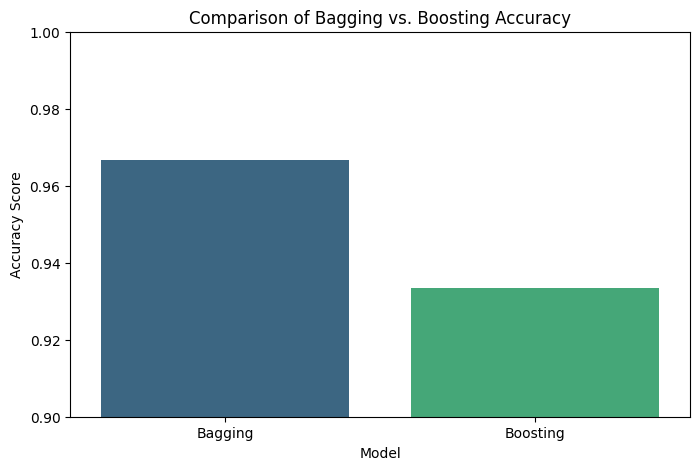

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Bagging vs. Boosting Accuracy')
plt.ylim(0.9, 1.0) # Set appropriate y-axis limits for better visualization
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.show()

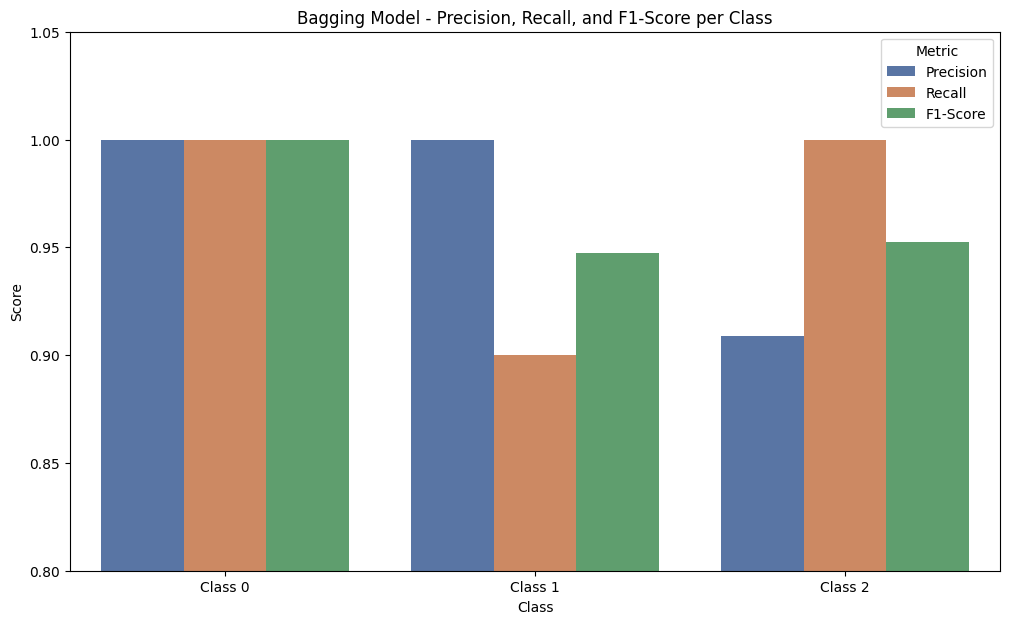

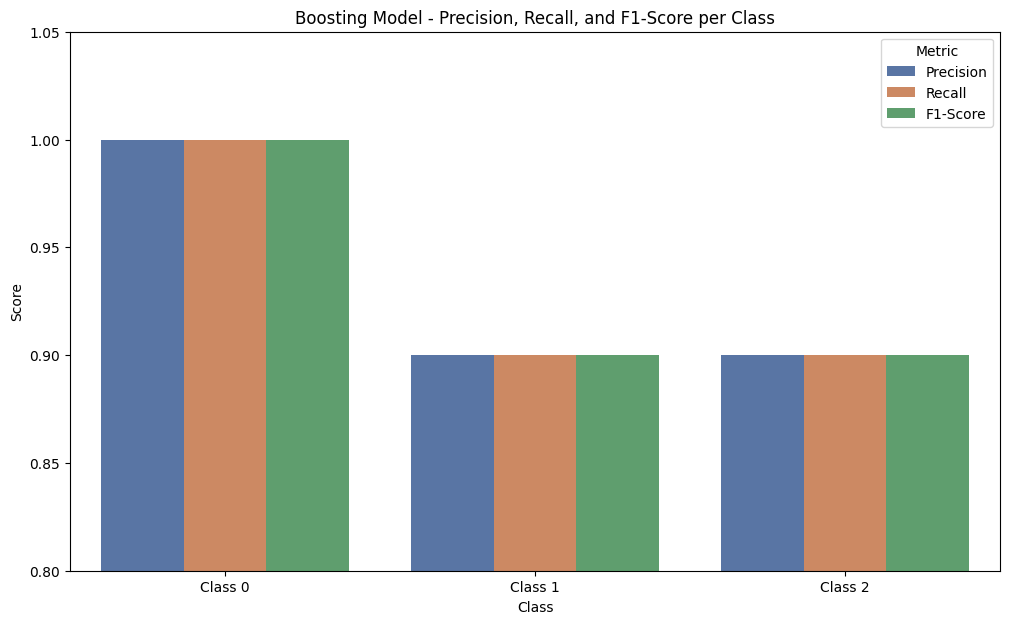

In [14]:
from sklearn.metrics import classification_report

# Get classification reports as dictionaries
bagging_report_dict = classification_report(y_test, y_pred_bagging, output_dict=True)
boosting_report_dict = classification_report(y_test, y_pred_boosting, output_dict=True)

# Prepare data for plotting
data_for_metrics_plot = []

for model_name, report_dict in [('Bagging', bagging_report_dict), ('Boosting', boosting_report_dict)]:
    for class_label in sorted([k for k in report_dict.keys() if k.isdigit()]):
        class_metrics = report_dict[class_label]
        data_for_metrics_plot.append({
            'Model': model_name,
            'Class': f'Class {class_label}',
            'Metric': 'Precision',
            'Score': class_metrics['precision']
        })
        data_for_metrics_plot.append({
            'Model': model_name,
            'Class': f'Class {class_label}',
            'Metric': 'Recall',
            'Score': class_metrics['recall']
        })
        data_for_metrics_plot.append({
            'Model': model_name,
            'Class': f'Class {class_label}',
            'Metric': 'F1-Score',
            'Score': class_metrics['f1-score']
        })

metrics_df = pd.DataFrame(data_for_metrics_plot)

plt.figure(figsize=(12, 7))
sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df[metrics_df['Model'] == 'Bagging'], palette='deep')
plt.title('Bagging Model - Precision, Recall, and F1-Score per Class')
plt.ylim(0.8, 1.05)
plt.ylabel('Score')
plt.xlabel('Class')
plt.legend(title='Metric')
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df[metrics_df['Model'] == 'Boosting'], palette='deep')
plt.title('Boosting Model - Precision, Recall, and F1-Score per Class')
plt.ylim(0.8, 1.05)
plt.ylabel('Score')
plt.xlabel('Class')
plt.legend(title='Metric')
plt.show()